# Background evolution of the field with CLASS
In this notebook we construct the numerical background evolution of an axion field $\chi_0$ and plot it versus redshift $z$. The equation of motion for this field is $$ \chi_0''+2\mathcal{H}\chi_0'+a(\tau)^2\frac{dV}{d\chi_0}=0\, , $$ where $'=\frac{d}{d\tau}$ and $\mathcal{H}$ is the Hubble ratio in conformal time.\ In this notebook, we will use CLASS in order not to compute numerically $H(a)$ and $a(\tau)$.
As before we imported all the necessary libraries, including Classy for *CLASS*.

In [272]:
import classy as cl
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

In this case we only need to explicitly define $M_{Pl}$ and $m_{Pl}$ since the other cosmological parameters will be defined inside *CLASS*.

In [273]:
ev_to_Mpc=1.5637e29
Mpl=1.22e28*ev_to_Mpc
mpl=Mpl/np.sqrt(8*np.pi)

Now we use *CLASS* to obtain the evolution of different quantities depending on the cosmological parameters that we input. In this case, as in the notebook for the numerical evolution, we used fiducial values for these parameters. To make sure of the units and the quantities, we printed the first line of the table that *CLASS* generates. In this case we are intersted just in $z$, $\tau$, $a(\tau)$ and $H$.

In [274]:
cosmo=cl.Class()
parameters={'h':0.6736, 'omega_b':0.02237, 'omega_cdm':0.12, 'A_s':2.1e-9, 'n_s':0.965, 'tau_reio':0.054}
cosmo.set(parameters)
cosmo.compute()
bg=cosmo.get_background()
print(bg.keys())

dict_keys(['z', 'proper time [Gyr]', 'conf. time [Mpc]', 'H [1/Mpc]', 'comov. dist.', 'ang.diam.dist.', 'lum. dist.', 'comov.snd.hrz.', '(.)rho_g', '(.)rho_b', '(.)rho_cdm', '(.)rho_lambda', '(.)rho_ur', '(.)rho_crit', '(.)rho_tot', '(.)p_tot', '(.)p_tot_prime', 'gr.fac. D', 'gr.fac. f'])


We extract the quantities mentioned before and transform $H$ into $\mathcal{H}$ by multiplying it by $a$.

In [275]:
tau=np.array(bg['conf. time [Mpc]'])
z=np.array(bg['z'])
a=np.array(1/(1+z))
H=np.array(bg['H [1/Mpc]'])
H_conformal=a*H

To compute the EOM i need to interpolate the points given by CLASS because *ScyPy* will require more points and much closer to each other to compute the differential equation.  After that, we also need to write, as in the other case, the derivative of the potential for the differential equation.

In [276]:
a_func_tau=sp.interpolate.interp1d(tau, a)
H_func_tau=sp.interpolate.interp1d(tau, H_conformal)

def V(x0, mx):
    return Mpl**2*mx**2*(1-np.cos(x0/Mpl))**2
def V_prime(x0, mx):
    return 2*Mpl*mx**2*np.sin(x0/Mpl)*(1-np.cos(x0/Mpl))
def eom(tau, y, mx):
    x0, vx=y
    return [vx, -2*H_func_tau(tau)*vx-a_func_tau(tau)**2*V_prime(x0, mx)]

From here the computation is very similar to the other scenario. We just need to input everything computed up to now in the differetial equation calculator, find $\chi_0(\tau)$ for each value of $m_\chi$ and then convert it into $\chi_0(z)$ for the plot.

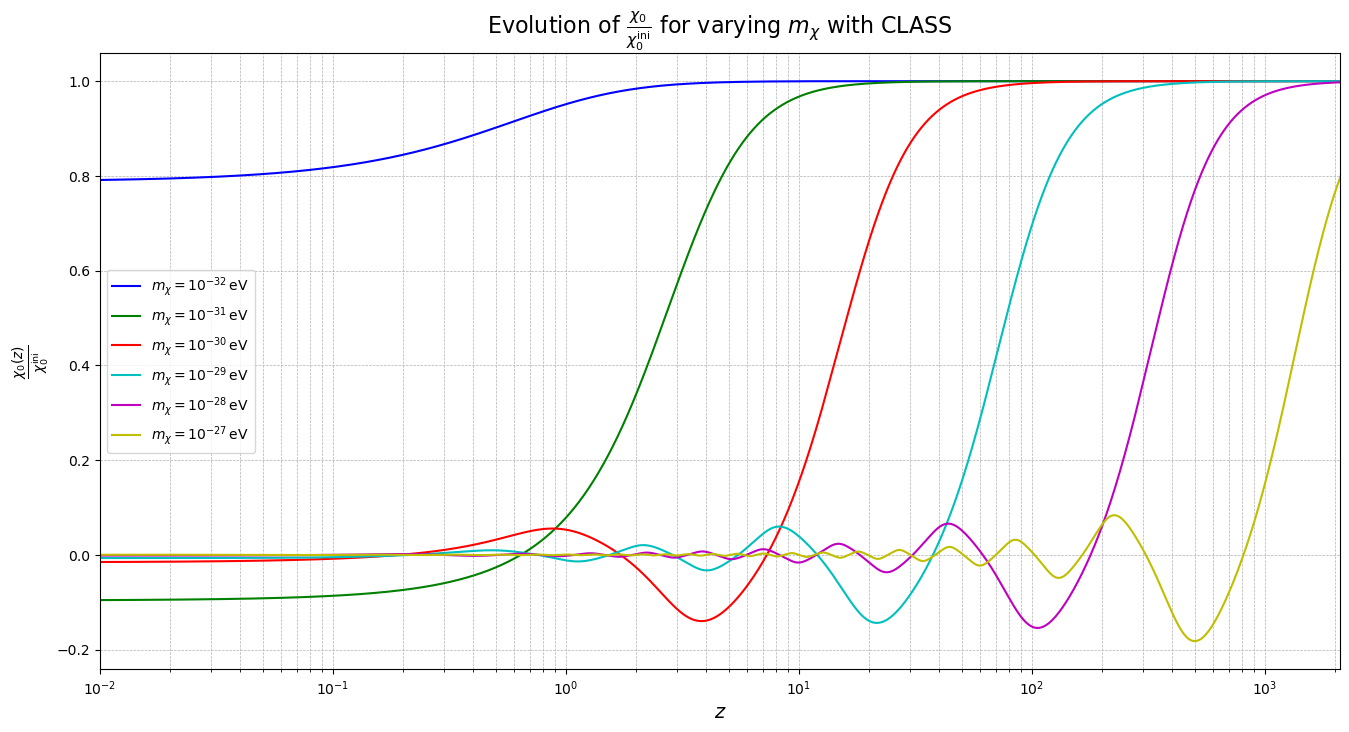

In [288]:
mx_values_Mpc=np.logspace(-32, -27, 6)*ev_to_Mpc
mx_values=[1e-32, 1e-31, 1e-30, 1e-29, 1e-28, 1e-27]

def LaTex_mass(mx_values):
    exp = int(np.log10(mx_values))
    return rf'10^{{{exp}}}\,\mathrm{{eV}}'

colors=['b', 'g', 'r', 'c', 'm', 'y']

plt.figure(figsize=(16, 8))
plt.xscale('log')

for mx_Mpc, mx, col in zip(mx_values_Mpc, mx_values, colors):
    initial_conditions=[mpl, 0]
    solution=sp.integrate.solve_ivp(eom, (tau[0], tau[-1]), initial_conditions, args=(mx_Mpc,), dense_output=True)
    x0_solution=solution.sol(tau)[0]/initial_conditions[0]

    plt.plot(z, x0_solution, color=col, label=rf'$m_\chi={LaTex_mass(mx)}$')
    



plt.xlabel(r'$z$', fontsize=14)
plt.xlim(1e-2, 2100)
plt.ylabel(r'$\frac{\chi_0(z)}{\chi_0^{\mathrm{ini}}}$', fontsize=14)
plt.grid(which='both', linestyle='--', linewidth=0.5)
plt.title(r'Evolution of $\frac{\chi_0}{\chi_0^{\rm ini}}$ for varying $m_\chi$ with CLASS', fontsize=16)
plt.legend()
plt.show()

The small differences between this case and the other in which we computed the evolution of the cosmological functions $a(\tau)$ and $\mathcal{H}$ are given by the small inaccuracies that the different numerical integrations carry with them. Overall the graphs have the same exact features and show the same exact evolution for the different masses given, and, most important, they match the ones in the paper "Probing Axions through Tomography of Anisotropic Cosmic Birefringence". 

Moreover, it is possible to compute the value of $\omega_{\chi_0}$, i.e. the ratio of the equation of state of $\chi_0$. To do so we can simply take the second result given by the integration of the equation of motion, $\chi_0'(\tau)=v_{\chi_0}$, and using the formula $$ \omega_{\chi_0}=\frac{\chi_0'-2a^2V(\chi_0)}{\chi_0'+2a^2V(\chi_0)}\, ,$$ we get the evolution of omega in redshift. 

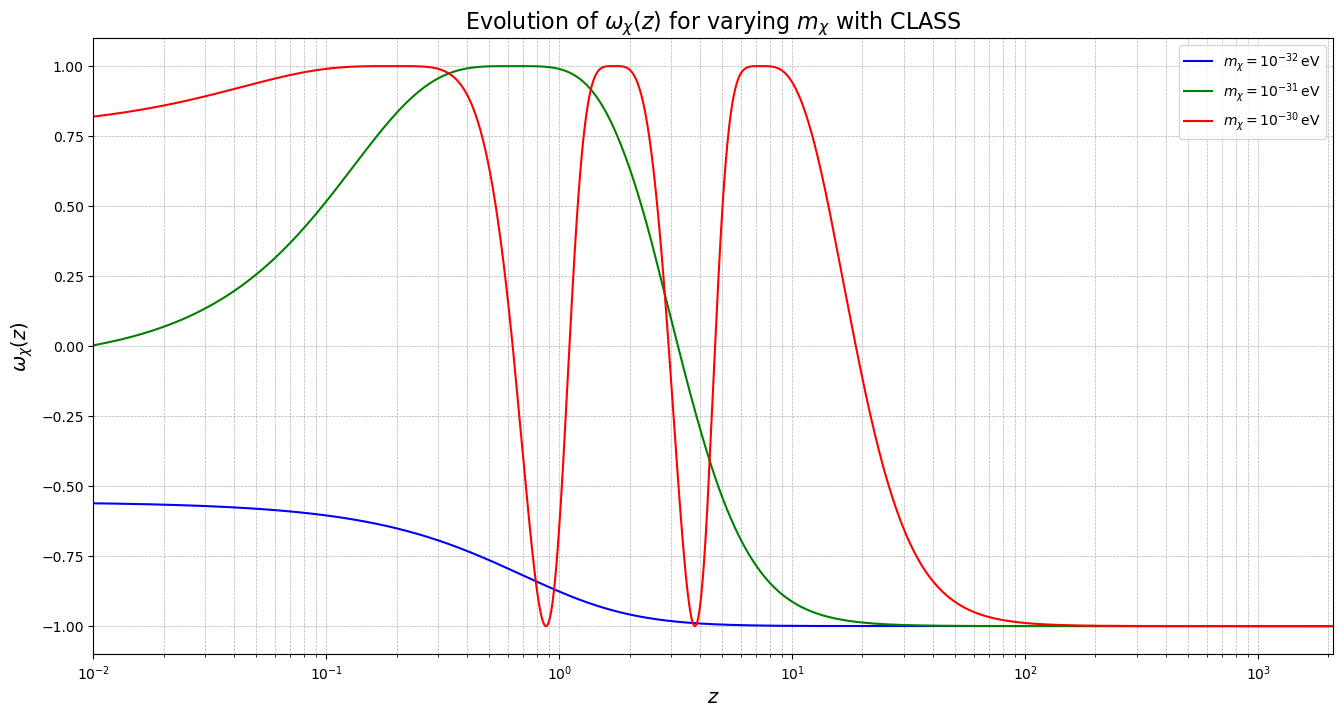

In [278]:
plt.figure(figsize=(16, 8))
plt.xscale('log')


mx_values_Mpc=np.logspace(-32, -30, 3)*ev_to_Mpc
for mx_Mpc, mx, col in zip(mx_values_Mpc, mx_values, colors):
    initial_conditions=[mpl, 0]
    solution=sp.integrate.solve_ivp(eom, (tau[0], tau[-1]), initial_conditions, args=(mx_Mpc,), dense_output=True)

    vx_solution=solution.sol(tau)[1]
    omega=(vx_solution**2-2*a_func_tau(tau)**2*V(solution.sol(tau)[0], mx_Mpc))/(vx_solution**2+2*a_func_tau(tau)**2*V(solution.sol(tau)[0], mx_Mpc))
    plt.plot(z, omega, color=col, label=rf'$m_\chi={LaTex_mass(mx)}$') 


plt.xlabel(r'$z$', fontsize=14)
plt.xlim(1e-2, 2100)
plt.ylabel(r'$\omega_\chi(z)$', fontsize=14)
plt.grid(which='both', linestyle='--', linewidth=0.5)
plt.title(r'Evolution of $\omega_\chi(z)$ for varying $m_\chi$ with CLASS', fontsize=16)
plt.legend()
plt.show() 

Here, the results show noticeable differences compared to the purely numerical approach. These arise primarily from small mismatches between CLASS-generated background quantities and those computed via direct integration. In the upcoming "Consistency Check" notebook, we will systematically investigate these discrepancies and refine the numerical results to improve agreement.

Like in the previous notebook, we ca procede in the same way for the computation of the density parameter of the axion field. In this case the known values for matter, radiation and $\Lambda$ are obtained directly from *CLASS*. For the matter one we need to account for both barions $(\rho_b)$ and cold dark matter $(\rho_{cdm})$. The same for the energy density of radiation, in which we need to account for both photons $(\rho_g)$ and neutrinos $(\rho_{ur})$.

In [279]:
rhocrit=np.array(bg['(.)rho_crit'])
Omegam=(np.array(bg['(.)rho_b'])+np.array(bg['(.)rho_cdm']))/rhocrit
Omegar=(np.array(bg['(.)rho_g'])+np.array(bg['(.)rho_ur']))/rhocrit
OmegaL=np.array(bg['(.)rho_lambda'])/rhocrit

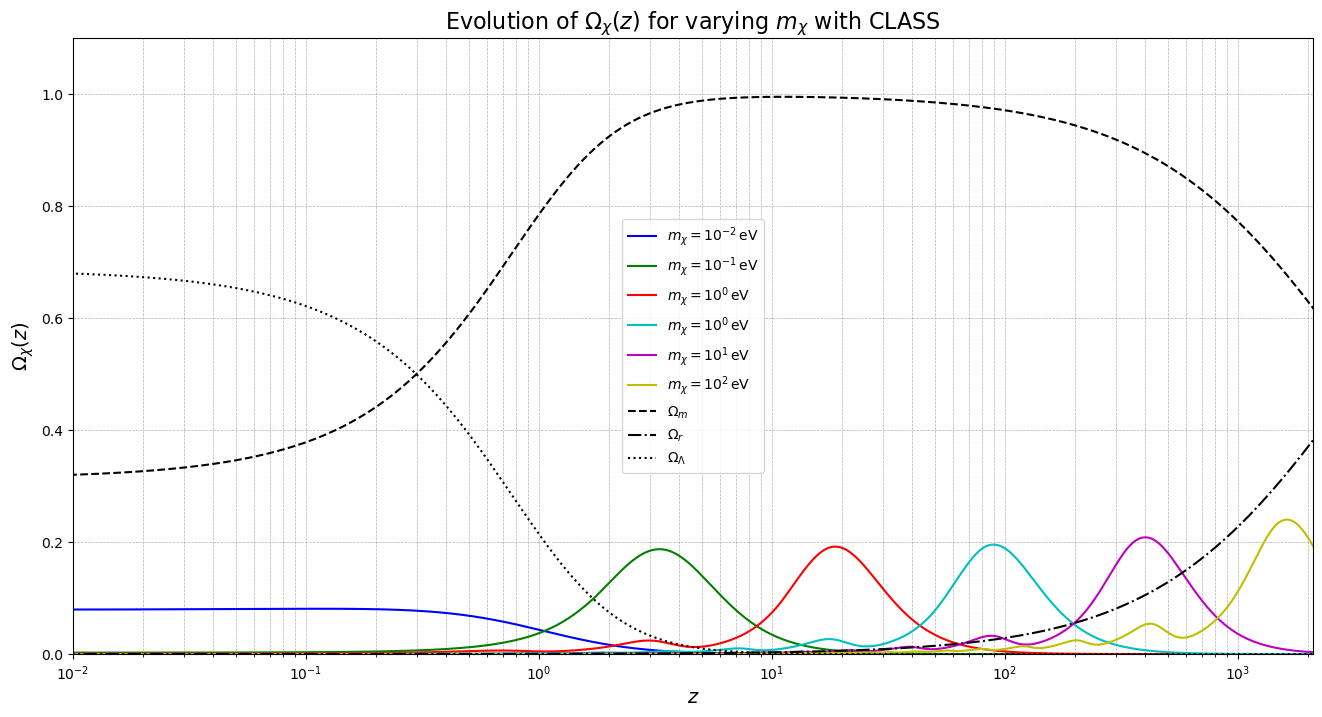

In [283]:
plt.figure(figsize=(16, 8))
plt.xscale('log')

mx_values_Mpc=np.logspace(-32, -27, 6)*ev_to_Mpc
mx_values=np.logspace(-32, -27, 6)

for mx_Mpc, mx, col in zip(mx_values_Mpc, mx_values, colors):
    initial_conditions=[mpl, 0]
    solution=sp.integrate.solve_ivp(eom, (tau[0], tau[-1]), initial_conditions, args=(mx_Mpc,), dense_output=True)
    vx_solution=solution.sol(tau)[1]

    rhox=0.5*(vx_solution/a_func_tau(tau))**2+V(solution.sol(tau)[0], mx_Mpc)
    Omegax=rhox/(3*mpl**2*rhocrit)
    plt.plot(z, Omegax, color=col, label=rf'$m_\chi={LaTex_mass(mx_Mpc)}$')

plt.plot(z, Omegam, 'k--', label=r'$\Omega_m$')
plt.plot(z, Omegar, 'k-.', label=r'$\Omega_r$')
plt.plot(z, OmegaL, 'k:', label=r'$\Omega_\Lambda$')
plt.xlabel(r'$z$', fontsize=14)
plt.xlim(1e-2, 2100)
plt.ylim(0, 1.1)
plt.ylabel(r'$\Omega_\chi(z)$', fontsize=14)
plt.grid(which='both', linestyle='--', linewidth=0.5)
plt.title(r'Evolution of $\Omega_\chi(z)$ for varying $m_\chi$ with CLASS', fontsize=16)
plt.legend()
plt.show()